# Ticketmaster API Explorer
This notebook interacts with the Ticketmaster Discovery API to query events and venues in the UK.

## 1. Imports & Setup

In [2]:
import requests
import os
import re
import time
from typing import Optional
from dotenv import load_dotenv
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt

## 2. Configuration
Load the API key from the `.env` file and define base URL constants.

In [3]:
load_dotenv()

API_KEY = os.getenv("TICKET_API")

if not API_KEY:
    raise ValueError("That API key is not in your env, check your env for the correct variable name.")

BASE_URL = "https://app.ticketmaster.com"

EVENTS_ENDPOINT = "/discovery/v2/events"
VENUES_ENDPOINT = "/discovery/v2/venues"

print("Config loaded successfully.")

Config loaded successfully.


## 3. Events
Query the Ticketmaster Discovery API for events in the UK.

In [4]:
api_key = API_KEY
all_events = []
current_page = 0
total_pages = 1 

while current_page < total_pages:
    events_url = f"{BASE_URL}{EVENTS_ENDPOINT}.json?apikey={api_key}&countryCode=GB&size=200&page={current_page}"
    events_response = requests.get(events_url).json()

    page_events = events_response.get('_embedded', {}).get('events', [])
    all_events.extend(page_events)

    total_pages = events_response.get('page', {}).get('totalPages', 1)
    current_page += 1

print(f"Successfully collected {len(all_events)} events total!")

Successfully collected 1200 events total!


In [5]:
uk_events = []


for event in all_events:
    class_list = event.get("classifications") or []
    cls = class_list[0] if class_list else {}

    venue_list = event.get("_embedded", {}).get("venues") or []
    vn = venue_list[0] if venue_list else {}

    market_list = vn.get("markets") or []
    mkt = market_list[0] if market_list else {}
    event_data = {
        "event_id": event.get("id"),
        "name": event.get("name"),
        "date": event.get("dates", {}).get("start", {}).get("localDate"),
        "time": event.get("dates", {}).get("start", {}).get("localTime"),
        "multi_day_event": event.get("dates", {}).get("spanMultipleDays"),
        "legal_age_enforced": event.get("ageRestrictions", {}).get("legalAgeEnforced"),

        "category_segment": cls.get("segment", {}).get("name"),
        "category_genre": cls.get("genre", {}).get("name"),
        "category_sub_genre": cls.get("subGenre", {}).get("name"),

        "all_inclusive_pricing": event.get("ticketing", {}).get("allInclusivePricing", {}).get("enabled"),

        "venue_id": vn.get("id"),
        "venue_name": vn.get("name"),
        "address": vn.get("address", {}).get("line1"),
        "postcode": vn.get("postalCode"),
        "city": vn.get("city", {}).get("name"),
        "longitude": vn.get("location", {}).get("longitude"),
        "latitude": vn.get("location", {}).get("latitude"),

        "markets": mkt.get("name"),
        "markets_id": mkt.get("id"),
        "url": event.get("url")
    }

    uk_events.append(event_data)

In [6]:
df_events = pd.DataFrame(uk_events)
df_events.head()

,event_id,name,date,time,multi_day_event,legal_age_enforced,category_segment,category_genre,category_sub_genre,all_inclusive_pricing,venue_id,venue_name,address,postcode,city,longitude,latitude,markets,markets_id,url
0,17u8v0G6Cr7i1p0,Philadelphia Eagles v Jacksonville Jaguars,2026-10-11,14:30:00,False,False,Sports,Football,NFL,False,KovZ9177OxV,Tottenham Hotspur Stadium,782 High Rd,N17 0BX,London,-0.06787000,51.60081900,All of United Kingdom,201,https://www.eticketing.co.uk/nfl-tottenham?utm...
1,17FYv0G65mKlspy,NFL London 2026: Houston Texans v Jacksonville...,2026-10-18,14:30:00,False,False,Sports,Football,NFL,False,KovZ9177ML0,Wembley Stadium,Wembley,HA9 0WS,London,-0.27958100,51.55780700,All of United Kingdom,201,https://www.eticketing.co.uk/jaguars/EDP/Event...
2,17u8v0G6CksBAD4,JAY-Z - 30,2026-09-04,17:00:00,False,False,Music,Hip-Hop/Rap,Trap,False,KovZ9177OxV,Tottenham Hotspur Stadium,782 High Rd,N17 0BX,London,-0.06787000,51.60081900,All of United Kingdom,201,https://www.ticketmaster.co.uk/jayz-30-london-...
3,17u8v0G6Cr7i1px,Indianapolis Colts v Washington Commanders,2026-10-04,14:30:00,False,False,Sports,Football,NFL,False,KovZ9177OxV,Tottenham Hotspur Stadium,782 High Rd,N17 0BX,London,-0.06787000,51.60081900,All of United Kingdom,201,https://www.eticketing.co.uk/nfl-tottenham?utm...
4,1AdjZbsGkiuEN60,Harry Potter and the Cursed Child - Parts 1 & ...,2026-07-15,14:00:00,False,False,Arts & Theatre,Theatre,Drama,False,KovZ9177gU0,Palace Theatre,"Cambridge Circus, Shaftesbury Avenue",W1D 8AY,London,-0.12970730,51.51316680,All of United Kingdom,201,https://theatre.ticketmaster.co.uk/book/17YYA-...


In [7]:
df_events.shape

(1200, 20)

# EDA

In [8]:
df_eda = df_events.copy()

city_counts = df_eda.groupby("city")["event_id"].count().reset_index(name = "event_count")

city_counts = city_counts.sort_values(by = "event_count", ascending = False).reset_index(drop = True)

In [10]:
city_counts.head()

,city,event_count
0,London,828
1,Bristol,65
2,Manchester,53
3,Glasgow,40
4,Edinburgh,39


In [9]:
colour_palette = ["#1A3A8F", # Deep navy blue — the dominant structural colour
               "#6B35C8", # Mid purple — the gradient midpoint
               "#00B4C8", # Teal/cyan — the upward arrow highlight
               "#0D1F5C", # Near-black navy — shadows and depth
               "#C8B8F0", # Pale lavender — for backgrounds or subtle fills
               "#F4F4F6"  # Off-white — clean background


]

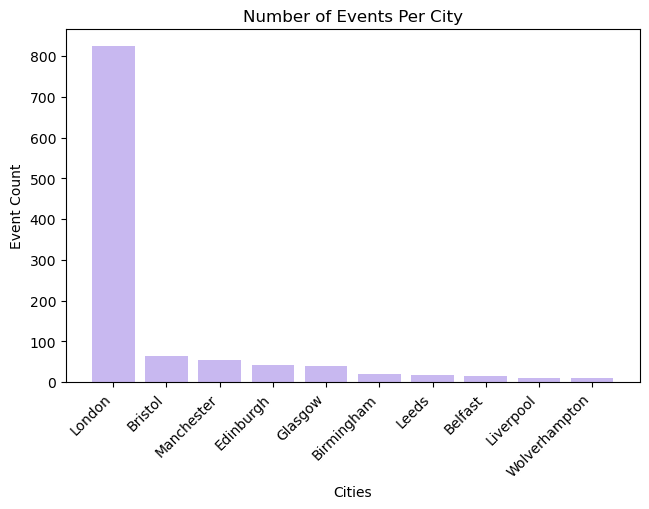

In [10]:
plt.bar(x = city_counts["city"].head(10), height = city_counts["event_count"].head(10), color = [colour_palette[4]])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.title("Number of Events Per City")
plt.xlabel("Cities")
plt.ylabel("Event Count")
plt.show()

## 4. Venues
Query the Ticketmaster Discovery API for venues in the UK and extract key fields.

In [11]:
api_key = API_KEY
all_venues = []
current_page = 0
total_pages = 1 

while current_page < total_pages:
    venues_url = f"{BASE_URL}{VENUES_ENDPOINT}.json?apikey={api_key}&countryCode=GB&size=200&page={current_page}"
    venues_response = requests.get(venues_url).json()

    page_venues = venues_response.get('_embedded', {}).get('venues', [])
    all_venues.extend(page_venues)

    total_pages = venues_response.get('page', {}).get('totalPages', 1)
    current_page += 1

print(f"Successfully collected {len(all_venues)} venues total!")

Successfully collected 1200 venues total!


In [12]:
uk_venues = []

for venue in all_venues:
    venue_data = {
        "id":         venue.get("id"),
        "name":       venue.get("name"),
        "city":       venue.get("city", {}).get("name"),
        "country":    venue.get("country", {}).get("name"),
        "longitude":  venue.get("location", {}).get("longitude"),
        "latitude":   venue.get("location", {}).get("latitude"),
        "postcode": venue.get("postalCode")
    }
    uk_venues.append(venue_data)

In [13]:
# Preview the first venue
pprint(uk_venues[0])

{'city': 'Dorset',
 'country': 'Great Britain',
 'id': 'KovZ9177-2f',
 'latitude': '50.73191800',
 'longitude': '-2.75789500',
 'name': 'Bridport Electric Palace',
 'postcode': 'DT63NY'}


In [14]:
df_venues = pd.DataFrame(uk_venues)
df_venues.head()

,id,name,city,country,longitude,latitude,postcode
0,KovZ9177-2f,Bridport Electric Palace,Dorset,Great Britain,-2.75789500,50.73191800,DT63NY
1,KovZ9177-37,St Martin's Theatre,London,Great Britain,-0.12767200,51.51284800,WC2H 9NZ
2,KovZ9177-A0,The Spotlight,Hoddesdon,Great Britain,-0.01507500,51.75569100,EN11 8BE
3,KovZ9177-AV,sohoplace,London,Great Britain,-0.13043600,51.51560700,W1D 3BG
4,KovZ9177-E0,Accu Stadium,Huddersfield,Great Britain,-1.76892400,53.65464900,HD16PG


## 5. Fetch Venue Capacity
Since the Ticketmaster API does not expose capacity data, we fetch it from Wikipedia
using the MediaWiki API. The function searches for each venue by name, pulls the raw
wikitext (infobox) and plain-text extract, then uses regex to extract the capacity value.

In [15]:
capacity_data_url = "https://drive.google.com/uc?export=download&id=1QtDJd2XOa51PyFGp_0ndDVHR1sLohLHd"

try:
    response = requests.get(capacity_data_url)
    response.raise_for_status() 

    with open('extracted_dictionary.txt', 'wb') as file:
        file.write(response.content)
    
    print("File downloaded and saved successfully.")

except Exception as e:
    print(f"Download failed! Check your URL or internet connection. Error: {e}")

try:
    with open("extracted_dictionary.txt", "r", encoding="utf-8") as f:
        file_content = f.read()

    file_content = file_content.replace('null', 'None')

    local_vars = {}
    exec(file_content, globals(), local_vars)

    extracted_data = local_vars.get("data")

    if extracted_data is not None:
        df_capacity = pd.DataFrame(extracted_data)
        print("\nDataFrame Head:")
        print(df_capacity.head())
        print(f"\nTotal rows: {len(df_capacity)}")
    else:
        print("Error: Could not find a 'data' variable inside the executed file.")

except FileNotFoundError:
    print("File not found, correct your logic or check your download url!")

File downloaded and saved successfully.

DataFrame Head:
             Venue_Name        Location  Total_Capacity
0  Glastonbury Festival          Pilton          210000
1     Download Festival  Donington Park          110000
2       Wembley Stadium          London           90000
3    Twickenham Stadium          London           82000
4        London Stadium          London           80000

Total rows: 324


In [16]:
df_capacity.shape

(324, 3)

In [17]:
df_capacity.rename(columns = {"Venue_Name" : "venue_name"}, inplace = True)

In [24]:
df_capacity.to_csv("df_capacity.csv")

In [18]:
df_venues.name.nunique()

1193

In [19]:
df_events.venue_name.nunique()

98

'''python
DataFrame.merge(right, how='inner', on=None, left_on=None, right_on=None, left_index=False, right_index=False, sort=False, suffixes=('_x', '_y'), copy=<no_default>, indicator=False, validate=None)[source]
'''

In [20]:
df_events = pd.merge(df_events, df_capacity, on='venue_name', how='left')

In [21]:
df_events.head()

,event_id,name,date,time,multi_day_event,legal_age_enforced,category_segment,category_genre,category_sub_genre,all_inclusive_pricing,...,address,postcode,city,longitude,latitude,markets,markets_id,url,Location,Total_Capacity
0,17u8v0G6Cr7i1p0,Philadelphia Eagles v Jacksonville Jaguars,2026-10-11,14:30:00,False,False,Sports,Football,NFL,False,...,782 High Rd,N17 0BX,London,-0.06787000,51.60081900,All of United Kingdom,201,https://www.eticketing.co.uk/nfl-tottenham?utm...,London,62000.0
1,17FYv0G65mKlspy,NFL London 2026: Houston Texans v Jacksonville...,2026-10-18,14:30:00,False,False,Sports,Football,NFL,False,...,Wembley,HA9 0WS,London,-0.27958100,51.55780700,All of United Kingdom,201,https://www.eticketing.co.uk/jaguars/EDP/Event...,London,90000.0
2,17u8v0G6CksBAD4,JAY-Z - 30,2026-09-04,17:00:00,False,False,Music,Hip-Hop/Rap,Trap,False,...,782 High Rd,N17 0BX,London,-0.06787000,51.60081900,All of United Kingdom,201,https://www.ticketmaster.co.uk/jayz-30-london-...,London,62000.0
3,17u8v0G6Cr7i1px,Indianapolis Colts v Washington Commanders,2026-10-04,14:30:00,False,False,Sports,Football,NFL,False,...,782 High Rd,N17 0BX,London,-0.06787000,51.60081900,All of United Kingdom,201,https://www.eticketing.co.uk/nfl-tottenham?utm...,London,62000.0
4,1AdjZbsGkiuEN60,Harry Potter and the Cursed Child - Parts 1 & ...,2026-07-15,14:00:00,False,False,Arts & Theatre,Theatre,Drama,False,...,"Cambridge Circus, Shaftesbury Avenue",W1D 8AY,London,-0.12970730,51.51316680,All of United Kingdom,201,https://theatre.ticketmaster.co.uk/book/17YYA-...,NaN,NaN


In [22]:
df_events.drop(columns= ["Location"], inplace = True)

In [23]:
df_events.rename(columns= {"Total_Capacity" : "total_capacity"}, inplace = True)

In [31]:
df_events.total_capacity.dtype

dtype('float64')

In [32]:
df_events.total_capacity.isnull().sum()

np.int64(983)

In [1]:
df_events.venue_name.nunique()

NameError: name 'df_events' is not defined

# Table of events per venue

In [17]:
cols_to_drop = ['date',	'time', 'multi_day_event', 'legal_age_enforced', 'category_segment', 'category_genre',	'category_sub_genre', 'all_inclusive_pricing','markets', 'markets_id', 'url', 'address','postcode','city']
try:
    df_dropped = df_events.drop(columns=cols_to_drop, errors='ignore')
    print("\nDataFrame after dropping columns:")
    print(df_dropped)
except KeyError as e:
    print(f"Error: {e}")


DataFrame after dropping columns:
             event_id                                               name  \
0     17u8v0G6Cr7i1p0         Philadelphia Eagles v Jacksonville Jaguars   
1     17FYv0G65mKlspy  NFL London 2026: Houston Texans v Jacksonville...   
2     17u8v0G6CksBAD4                                         JAY-Z - 30   
3     17u8v0G6Cr7i1px         Indianapolis Colts v Washington Commanders   
4     1AdjZbsGkiuENAI  Harry Potter and the Cursed Child - Parts 1 & ...   
...               ...                                                ...   
1195  17uOv0G6GGkRApA                     Back to the Future The Musical   
1196  17uOv0G6GGkxgoM                     Back to the Future The Musical   
1197  17uOv0G6uJYDc4y                     Back to the Future The Musical   
1198  17uOv0G6uJsaW9N                     Back to the Future The Musical   
1199  17uOv0G6uJsbu_v                     Back to the Future The Musical   

         venue_id                 venue_name    long

In [19]:
venue_counts = df_dropped.groupby(['venue_id','venue_name','longitude', 'latitude']).size().reset_index(name='events_per_venue')
venue_counts.head()

,venue_id,venue_name,longitude,latitude,events_per_venue
0,KovZ91770_0,Utilita Arena Sheffield,-1.41882500,53.39978600,4
1,KovZ91770_V,Sheffield City Hall Oval Hall,-1.47107900,53.38118000,1
2,KovZ91771HV,O2 Institute Birmingham,-1.88756200,52.47575600,1
3,KovZ91775qf,Albert Hall,-2.24889100,53.47840200,5
4,KovZ91776F7,Bournemouth Pavilion,-1.87516600,50.71754400,8


In [20]:
import plotly.express as px

fig = px.bar(
    venue_counts, 
    x="venue_name", 
    y="events_per_venue",
    title="Number of Events per Venue",
    labels={"venue_name": "Venue Name", "events_per_venue": "Number of Events"},
    hover_name="venue_name", # This puts the venue name in bold at the top of the tooltip
    color="events_per_venue",     # Optional: adds a nice color gradient based on counts
    height = 600,
    color_continuous_scale="Viridis"
)


fig.update_layout(
    xaxis_tickangle=-45, # Tilts the venue names so they don't overlap
    plot_bgcolor="rgba(0,0,0,0)" # Gives it a clean white background
)


fig.show()


In [21]:
import streamlit as st

venue_counts['latitude'] = pd.to_numeric(venue_counts['latitude'], errors='coerce')
venue_counts['longitude'] = pd.to_numeric(venue_counts['longitude'], errors='coerce')

# Remove any rows with invalid coordinates (NaN values)
venue_counts = venue_counts.dropna(subset=['latitude', 'longitude'])

# Create the scatter map with properly formatted numeric coordinates
map = px.scatter_map(
    venue_counts, 
    lat="latitude", 
    lon="longitude", 
    hover_name="venue_name", 
    size="events_per_venue",
    color="events_per_venue",
    zoom=1, 
    height=400
)

# Tell Plotly to use open-street-map (so you don't need a Mapbox API token)
map.update_layout(mapbox_style="open-street-map")
map.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

# Display map in python
map.show()

# Display the map in Streamlit
st.plotly_chart(map)

2026-07-09 15:33:03.230 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 15:33:03.232 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 15:33:03.235 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 15:33:03.706 
  command:

    streamlit run c:\Users\Hilary\AppData\Local\Programs\Python\Python313\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-09 15:33:03.708 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 15:33:03.709 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [ ]:
city_counts = df_events.groupby('city')['event_id'].count()
venue_counts = df_events.groupby('city')
venue_counts = venue_counts['venue_id'].nunique()
venue_counts = venue_counts.reset_index()
city_counts = city_counts.reset_index()
ratios = city_counts.merge(venue_counts, on='city', how='inner')
ratios['ratio'] = ratios['event_id'] / ratios['venue_id']
ratios.sort_values(by='ratio', ascending=False)

,city,event_id,venue_id,ratio
21,London,846,24,35.250000
7,Bristol,66,4,16.500000
38,Wolverhampton,10,1,10.000000
4,Bournemouth,8,1,8.000000
10,Cheshire,8,1,8.000000
32,Scarborough,8,1,8.000000
6,Brighton,13,2,6.500000
19,Leeds,18,3,6.000000
39,York,6,1,6.000000
22,Manchester,53,9,5.888889


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38],
 [Text(0, 0, 'Bristol'),
  Text(1, 0, 'Wolverhampton'),
  Text(2, 0, 'Bournemouth'),
  Text(3, 0, 'Cheshire'),
  Text(4, 0, 'Scarborough'),
  Text(5, 0, 'Brighton'),
  Text(6, 0, 'Leeds'),
  Text(7, 0, 'York'),
  Text(8, 0, 'Manchester'),
  Text(9, 0, 'Glasgow'),
  Text(10, 0, 'Cardiff'),
  Text(11, 0, 'Derby'),
  Text(12, 0, 'Halifax'),
  Text(13, 0, 'Norfolk'),
  Text(14, 0, 'Hull'),
  Text(15, 0, 'Belfast'),
  Text(16, 0, 'Birmingham'),
  Text(17, 0, 'Reading'),
  Text(18, 0, 'Greenwich'),
  Text(19, 0, 'Newcastle Upon Tyne'),
  Text(20, 0, 'Liverpool'),
  Text(21, 0, 'Basingstoke'),
  Text(22, 0, 'Bradford'),
  Text(23, 0, 'Dorset'),
  Text(24, 0, 'Stevenage'),
  Text(25, 0, 'Suffolk'),
  Text(26, 0, 'Sheffield'),
  Text(27, 0, 'Nottingham'),
  Text(28, 0, 'Sou

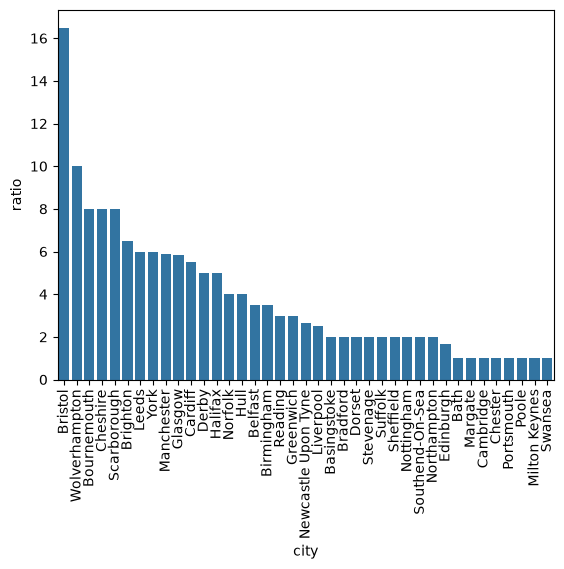

In [29]:
import seaborn as sns

sns.barplot(ratios.drop(index=21).sort_values(by='ratio', ascending=False), x='city', y='ratio')
plt.xticks(rotation=90)